In [1]:
import re
import matplotlib.pyplot as plt

def parse_and_plot_qemu_log(filename):
    import matplotlib.pyplot as plt

    # 初始化字典，用于存储不同 eid 的数据
    data_by_eid = {}

    # 正则表达式提取变量
    pattern = re.compile(
        r"eid:\s*(\d+),\s*current_ptime:\s*(\d+),\s*etime:\s*(\d+),\s*ptime:\s*(\d+),\s*ptime_interrupt:\s*(\d+),\s*time_debt:\s*(-?\d+)d"
    )

    with open(filename, 'r') as f:
        for line in f:
            match = pattern.search(line)
            if match:
                eid = int(match.group(1))
                current_ptime = int(match.group(2))
                etime = int(match.group(3))
                ptime = int(match.group(4))
                ptime_interrupt = int(match.group(5))
                time_debt = int(match.group(6))
                
                # 如果 eid 不在字典中，初始化数据结构
                if eid not in data_by_eid:
                    data_by_eid[eid] = {
                        "current_ptime": [],
                        "etime": [],
                        "ptime": [],
                        "ptime_interrupt": [],
                        "time_debt": []
                    }
                
                # 添加数据到对应 eid 的列表中
                data_by_eid[eid]["current_ptime"].append(current_ptime)
                data_by_eid[eid]["etime"].append(etime)
                data_by_eid[eid]["ptime"].append(ptime)
                data_by_eid[eid]["ptime_interrupt"].append(ptime_interrupt)
                data_by_eid[eid]["time_debt"].append(time_debt)

    # 绘图
    fig, axs = plt.subplots(4, 1, figsize=(10, 18), sharex=True)

    # 绘制 ptime_interrupt
    for eid, data in data_by_eid.items():
        axs[0].plot(data["current_ptime"], data["ptime_interrupt"], label=f'eid {eid}')
    axs[0].set_ylabel('ptime_interrupt')
    axs[0].legend()
    axs[0].autoscale()

    # 绘制 y=x 基准线
    min_val = min(min(data["current_ptime"]) for data in data_by_eid.values())
    max_val = max(max(data["current_ptime"]) for data in data_by_eid.values())
    axs[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')
    axs[0].legend()

    # 绘制 time_debt
    for eid, data in data_by_eid.items():
        axs[1].plot(data["current_ptime"], data["time_debt"], label=f'eid {eid}')
    axs[1].set_ylabel('time_debt')
    axs[1].legend()
    axs[1].autoscale()

    # 绘制 etime
    for eid, data in data_by_eid.items():
        axs[2].plot(data["current_ptime"], data["etime"], label=f'eid {eid}')
    axs[2].set_ylabel('etime')
    axs[2].legend()
    axs[2].autoscale()

    # 绘制 ptime
    for eid, data in data_by_eid.items():
        axs[3].plot(data["current_ptime"], data["ptime"], label=f'eid {eid}')
    axs[3].set_ylabel('ptime')
    axs[3].set_xlabel('current_ptime')
    axs[3].legend()
    axs[3].autoscale()

    plt.tight_layout()
    plt.show()

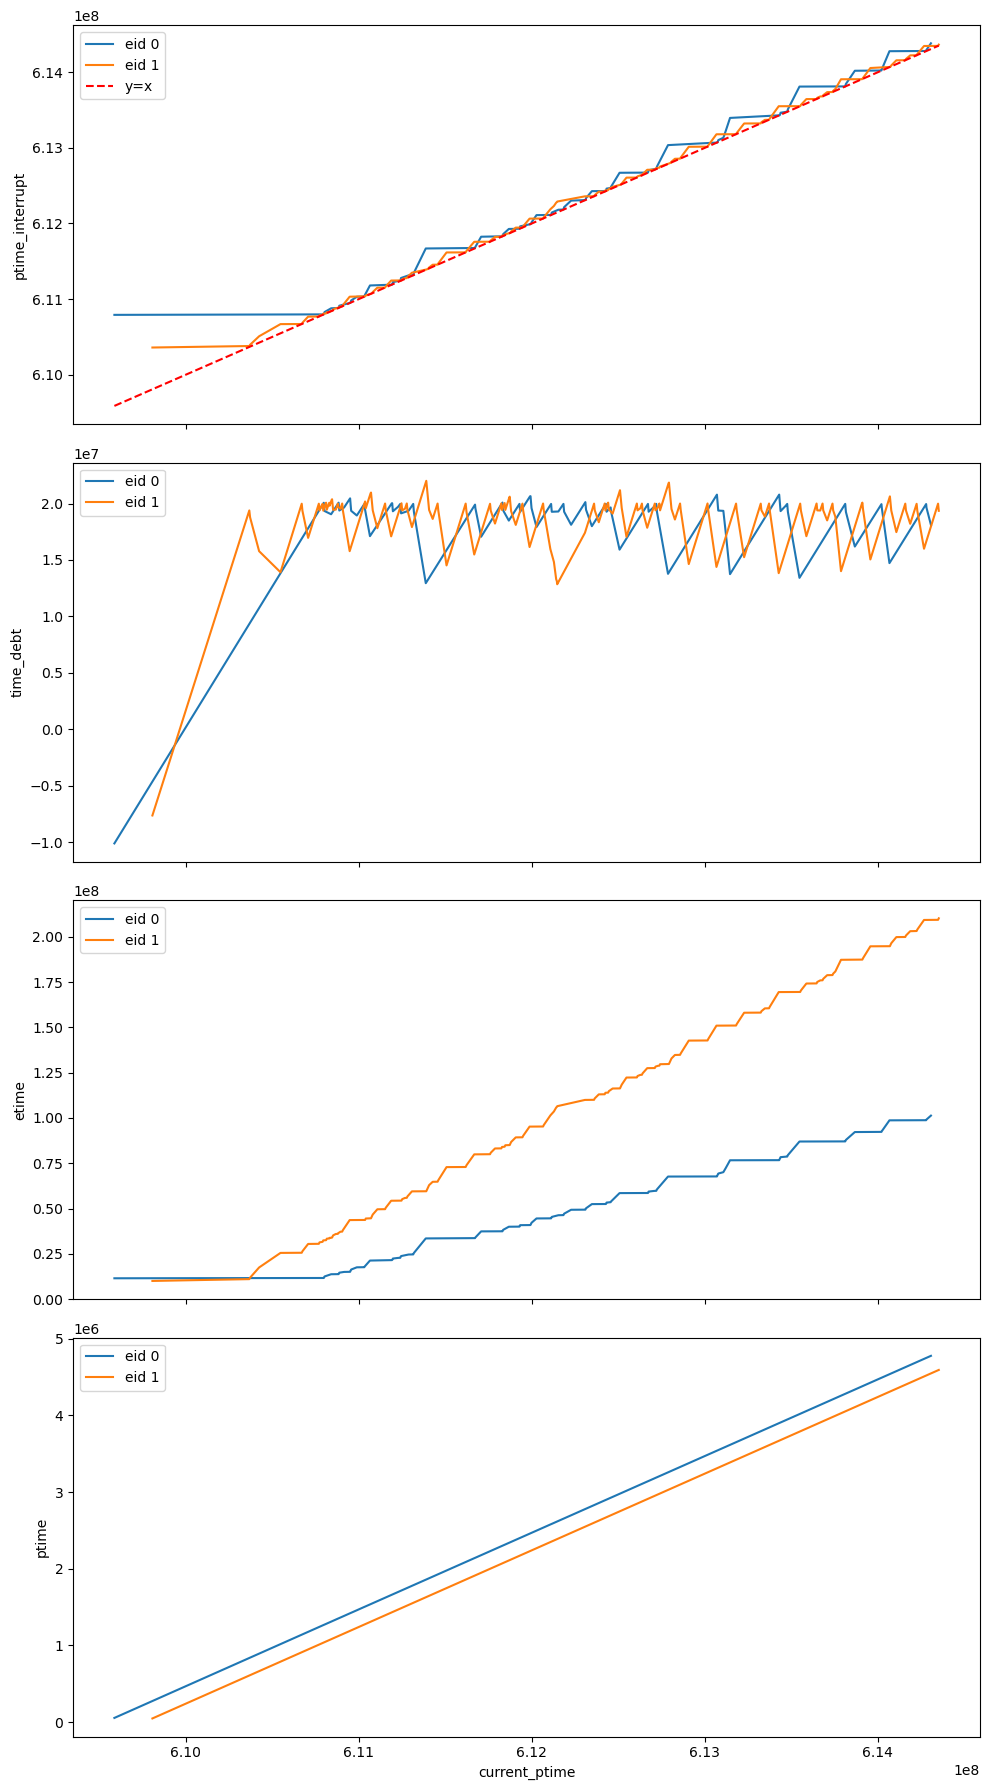

In [ ]:
# Qemu, Defend, Stress cpu 32, 2 processes
parse_and_plot_qemu_log('qemu1.txt')

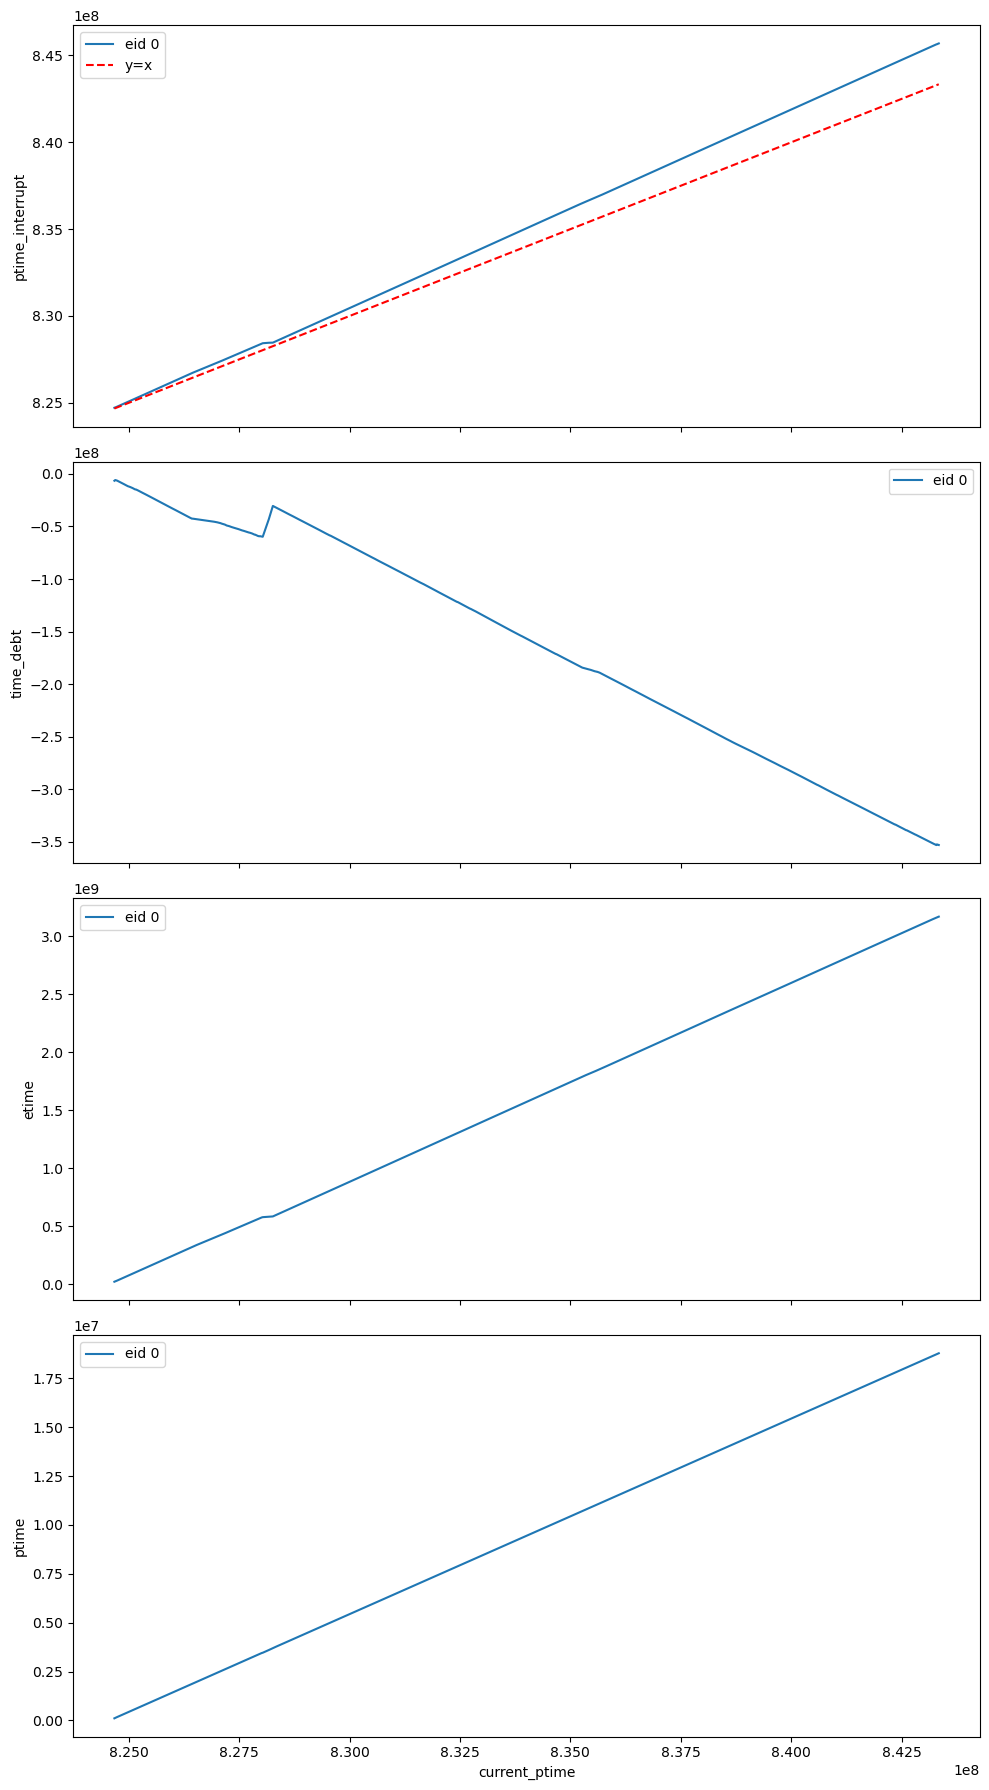

In [8]:
parse_and_plot_qemu_log('qemu_normal_defend_coremark.txt')

Coremark scores
* qemu
stress/defend   no-defend defend
nostress        4538      4581 
stress64       62        2984

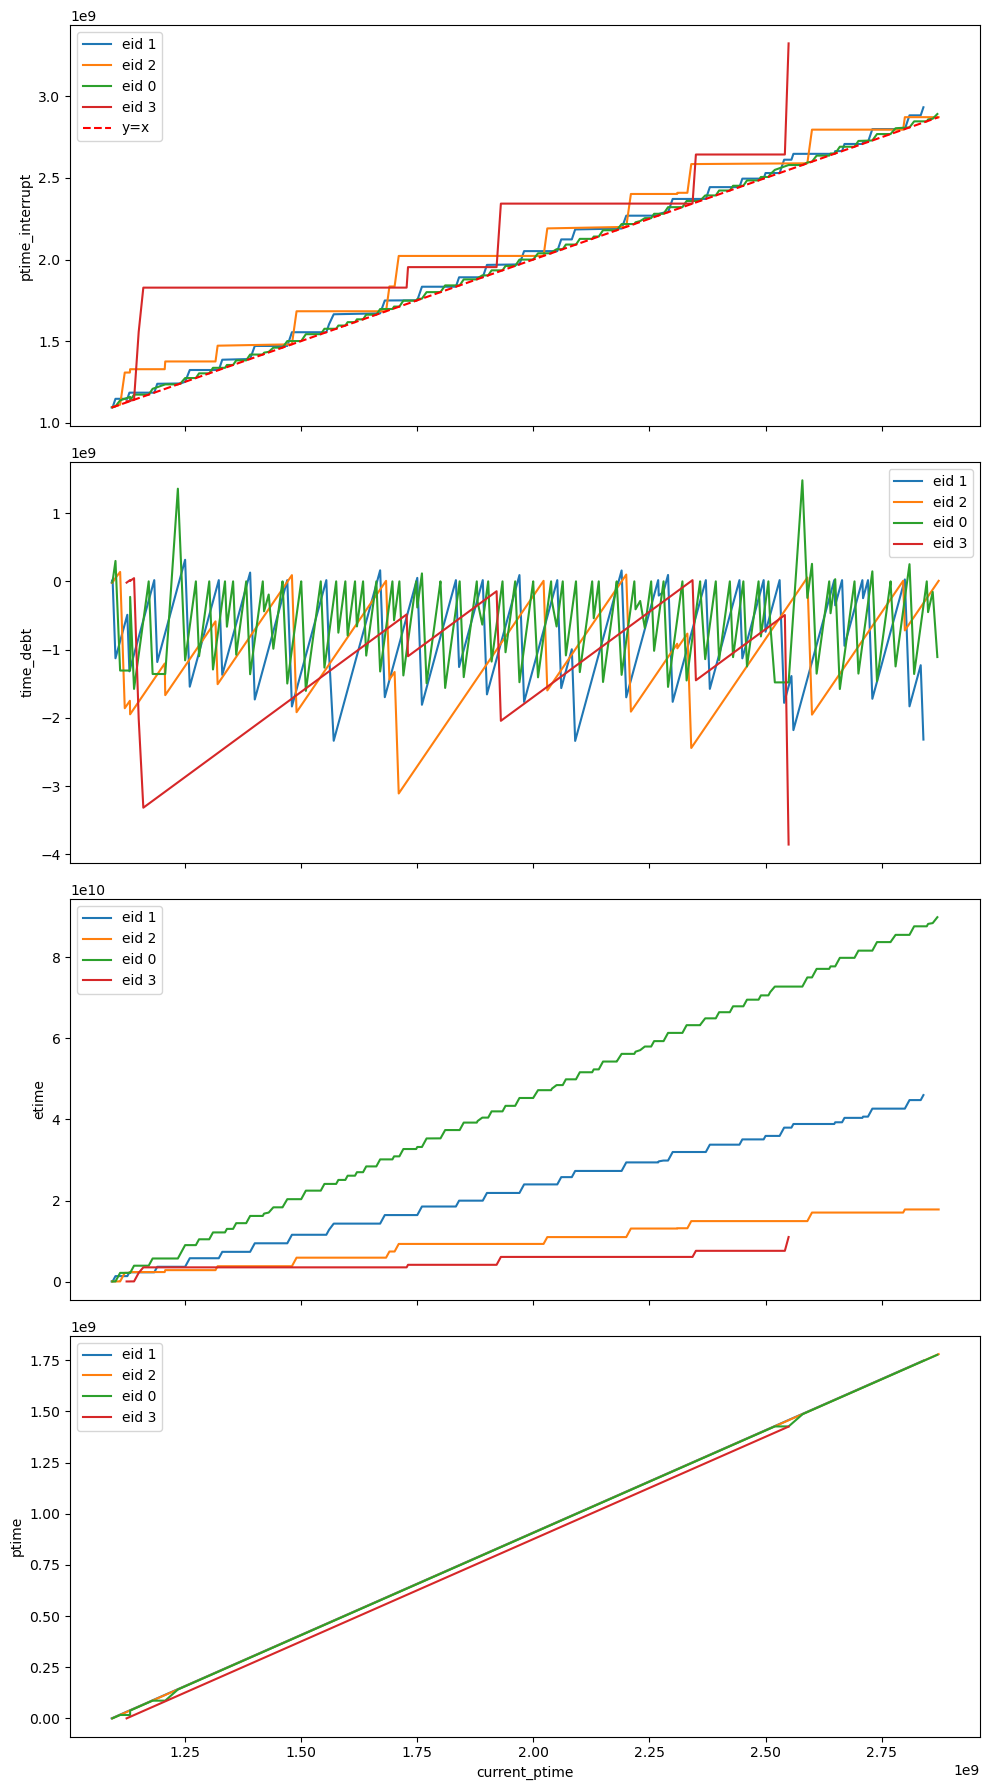

In [5]:
parse_and_plot_qemu_log('qemu_output_new.txt')

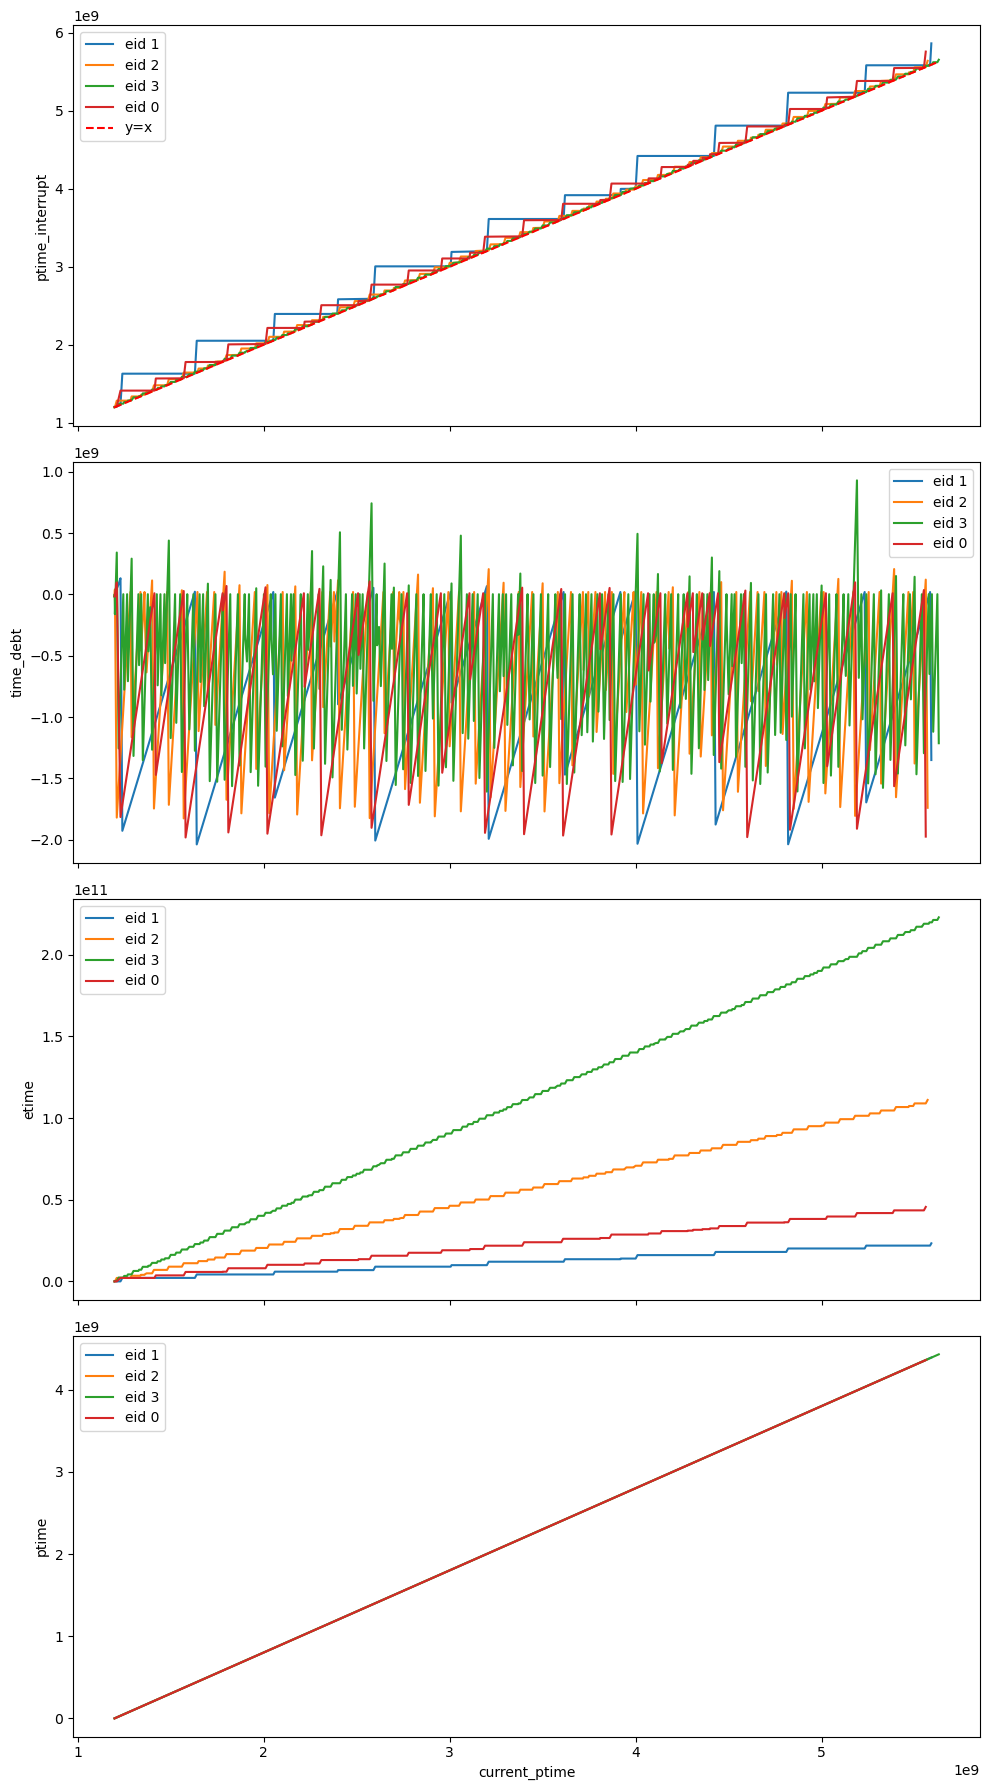

In [2]:
parse_and_plot_qemu_log('qemu_output.txt')